### QUEST 01 — From SLR to MLR (Extending the Model)
#### Q1. SLR Recap — Write the SLR Equation

**Equation**

y^=β0+β1x

Definitions
| Symbol | Meaning              |
| ------ | -------------------- |
| ŷ      | Predicted value of y |
| β₀     | Intercept            |
| β₁     | Slope coefficient    |
| x      | Independent variable |


#### Q2. MLR Model — Multiple Linear Regression
**Equation**

y^i=β0+β1xi1+β2xi2+⋯+βkxik+εi

Definitions

| Symbol    | Meaning                           |
| --------- | --------------------------------- |
| ŷᵢ        | Predicted value for observation i |
| β₀        | Intercept                         |
| β₁...βₖ   | Regression coefficients           |
| xᵢ₁...xᵢₖ | Predictor values                  |
| k         | Number of predictors              |
| i         | Observation number                |
| εᵢ        | Random error term                 |


#### Q3. Why Multiple Predictors?
**House Price Example**

Using only:
x₁ = Area

is not enough.

Additional Features

| Feature                 | Why It Helps                    |
| ----------------------- | ------------------------------- |
| x₂ = Location           | Prime locations cost more       |
| x₃ = Number of Bedrooms | Larger families need more rooms |
| x₄ = Property Age       | Newer homes usually sell higher |
| x₅ = Parking Spaces     | Adds convenience and value      |


#### Q4. Partial Slope Interpretation
**Model**

Salary=5000+800(Experience)+300(Certifications)

**Interpretation of β₁ = 800**

Holding all other variables constant,
each additional year of experience increases expected salary by ₹800.


#### Q5. Difference Between SLR and MLR R²
**SLR**
R² measures variance explained by one predictor.

**MLR**
R² measures variance explained by multiple predictors.

**Problem**
R² always increases when predictors are added, even if those predictors are useless.

**Metric That Fixes This**

✅ Adjusted R²

Formula:

Adjusted R2=1−(1−R2)(n−1)/n−k−1
Adjusted R² penalizes unnecessary predictors.


#### Q6. Assumptions of Multiple Linear Regression

MLR inherits the five assumptions of SLR and adds one more.

| No | Assumption                   |
| -- | ---------------------------- |
| 1  | Linearity                    |
| 2  | Independence of Errors       |
| 3  | Homoscedasticity             |
| 4  | Normality of Residuals       |
| 5  | No Multicollinearity         |
| 6  | No Perfect Multicollinearity |




In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
data = {
    'Area':[1000,1200,1500,1800,2000],
    'Bedrooms':[2,2,3,3,4],
    'Age':[10,8,6,5,3],
    'Price':[30,35,45,50,60]
}

df = pd.DataFrame(data)

X = df[['Area','Bedrooms','Age']]
y = df['Price']

model = LinearRegression()

model.fit(X,y)

print("Intercept (β0):", model.intercept_)

print("\nCoefficients")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

r2 = model.score(X,y)

print("\nR² Score:", round(r2,4))

Intercept (β0): 22.045454545414344

Coefficients
Area : 0.011363636363663164
Bedrooms : 4.696969696969694
Age : -1.2878787878787863

R² Score: 0.9993


In [4]:
new_house = [[1700,3,4]]

predicted_price = model.predict(new_house)

print("Predicted Price:", predicted_price[0])

Predicted Price: 50.303030303035655


C:\Users\Disha lukhi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### QUEST 02 — The Design Matrix (Building X)
#### Q1. Dataset

| Observation | x₁ | x₂ | y  |
| ----------- | -- | -- | -- |
| 1           | 2  | 3  | 14 |
| 2           | 4  | 1  | 16 |
| 3           | 6  | 5  | 26 |


Number of observations:
- n=3

Number of predictors:
- k=2

#### Q2. Write the Design Matrix X
In Multiple Linear Regression, the Design Matrix X has dimensions:

- n×(k+1)

since:
n=3,k=2
X=(3×3)

The first column contains all 1s for the intercept term β0.

Therefore,

X= 1 2 3
   1 4 1
   1 6 5

Explanation
- Column 1 → Intercept column
- Column 2 → Feature x1
- Column 3 → Feature x2


#### Q3. Write the Response Vector y

The response vector contains all target values.

y= 14
   16
   26

Dimensions:

(3×1)
	​

#### Q4. Write the Coefficient Vector β

The coefficient vector contains all model parameters.

β=β0
  β1
  β2
	
Dimensions:
              (3×1)

Where:
- β0= Intercept
- β1= Coefficient for x1
- β2= Coefficient for x2

#### Q5. Matrix Model Equation
The Multiple Linear Regression model in matrix form is:

y=Xβ+ε

Substituting the matrices:

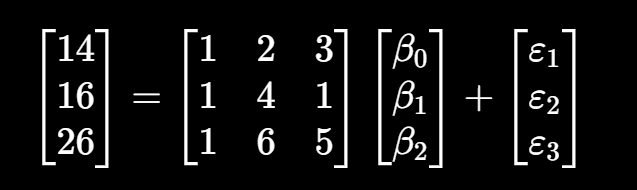


#### Dimension Verification

**Response vector:**

(3×1)

**Design Matrix:**

(3×3)

**Coefficient Vector:**

(3×1)

**Multiplication:**

(3×3)(3×1)=(3×1)

**Adding residual vector:**

(3×1)+(3×1)=(3×1)


Q6. Why a Column of 1s?

The intercept β
0
	​

 is a constant value that affects every observation equally.

Without the column of 1s:

X= 2 3 
   4 1
   6 5
	​


the matrix multiplication would only produce:

β1x1+β2x2​


and the intercept term would be missing.

Adding a column of 1s gives:

1×β0
	​
for every row.

Thus the model becomes:
y^=β0+β1x1+β2x2
	​


which correctly includes the intercept.


In [6]:
X = np.array([
    [1, 2, 3],
    [1, 4, 1],
    [1, 6, 5]
])

# Response Vector
y = np.array([
    [14],
    [16],
    [26]
])

print("Design Matrix X:")
print(X)

print("\nResponse Vector y:")
print(y)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Example coefficient vector
beta = np.array([
    [1],
    [2],
    [3]
])

print("\nCoefficient Vector β:")
print(beta)

print("\nShape of β:", beta.shape)

# Predicted values
y_hat = X @ beta

print("\nPredicted Values:")
print(y_hat)

Design Matrix X:
[[1 2 3]
 [1 4 1]
 [1 6 5]]

Response Vector y:
[[14]
 [16]
 [26]]

Shape of X: (3, 3)
Shape of y: (3, 1)

Coefficient Vector β:
[[1]
 [2]
 [3]]

Shape of β: (3, 1)

Predicted Values:
[[14]
 [12]
 [28]]


### QUEST 03 — Normal Equations in Matrix Form (Notebook Style)

### Q1. Cost Function in Matrix Form

The Multiple Linear Regression (MLR) cost function is:

L(β)=(y−Xβ)T(y−Xβ)

Where:

- y = response vector
- X = design matrix
- β = coefficient vector

This expression measures the total squared prediction error.

Since:

y^=Xβ

then

L(β)=n∑i=1(yi−y^i)2

Therefore:

L(β)=SSE

where SSE = Sum of Squared Errors.


Q2. Expand L(β)

Start with:

L(β)=(y−Xβ)T(y−Xβ)

Using transpose rules:

(y−Xβ)T=yT−(Xβ)T
(y−Xβ)T=yT−βT.XT

Substitute:

L(β)=(yT−βT.XT)(y−Xβ)

Multiply term-by-term:

L(β)=yT.y−yT.Xβ−βT.XT.y+βT.XT.Xβ

Since yT.Xβ is a scalar:

yT.Xβ=βT.XT.y

Therefore:

L(β)=yT.y−2βT.XT.y+βT.XT.Xβ

# Q3. Differentiate \(L(\beta)\)

### Starting Expression

\[
L(\beta)=y^Ty-2\beta^TX^Ty+\beta^TX^TX\beta
\]

### Useful Matrix Calculus Rules

\[
\frac{\partial}{\partial \beta}
(\beta^TX^Ty)=X^Ty
\]

\[
\frac{\partial}{\partial \beta}
(\beta^TX^TX\beta)=2X^TX\beta
\]

### Derivative of Constant Term

\[
\frac{\partial}{\partial \beta}(y^Ty)=0
\]

### Differentiate the Cost Function

\[
\frac{\partial L}{\partial \beta}
=
0-2X^Ty+2X^TX\beta
\]

Therefore,

\[
\nabla_{\beta}L
=
-2X^Ty+2X^TX\beta
\]

---

# Q4. Set Gradient Equal to Zero

For minimum cost:

\[
\frac{\partial L}{\partial \beta}=0
\]

Substitute the gradient:

\[
-2X^Ty+2X^TX\beta=0
\]

Divide both sides by 2:

\[
-X^Ty+X^TX\beta=0
\]

Move \(X^Ty\) to the right side:

\[
X^TX\beta=X^Ty
\]

This is called the **Matrix Normal Equation**.

---

# Q5. Interpret the Normal Equation

### Matrix Normal Equation

\[
X^TX\beta=X^Ty
\]

## Dimensions

### Design Matrix

\[
X=(n\times(k+1))
\]

### Transpose

\[
X^T=((k+1)\times n)
\]

Therefore,

\[
X^TX=
((k+1)\times n)
(n\times(k+1))
=
((k+1)\times(k+1))
\]

and

\[
X^Ty=
((k+1)\times n)
(n\times1)
=
((k+1)\times1)
\]

Thus,

\[
((k+1)\times(k+1))
((k+1)\times1)
=
((k+1)\times1)
\]

Dimensions are valid.

---

## Meaning of \(X^TX\)

\(X^TX\) contains:

- Feature variances
- Feature correlations
- Relationships among predictors

It summarizes how all predictors relate to one another.

---

## Meaning of \(X^Ty\)

\(X^Ty\) measures:

- Relationship between predictors and target variable

---

# Q6. Connection to Simple Linear Regression (SLR)

For one predictor:

\[
X=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\]

Then

\[
X^TX=
\begin{bmatrix}
n & \sum x_i \\
\sum x_i & \sum x_i^2
\end{bmatrix}
\]

and

\[
X^Ty=
\begin{bmatrix}
\sum y_i \\
\sum x_i y_i
\end{bmatrix}
\]

Substitute into:

\[
X^TX\beta=X^Ty
\]

\[
\begin{bmatrix}
n & \sum x_i \\
\sum x_i & \sum x_i^2
\end{bmatrix}
\begin{bmatrix}
\beta_0 \\
\beta_1
\end{bmatrix}
=
\begin{bmatrix}
\sum y_i \\
\sum x_i y_i
\end{bmatrix}
\]

### Matrix Multiplication

#### First Equation

\[
n\beta_0+\beta_1\sum x_i
=
\sum y_i
\]

#### Second Equation

\[
\beta_0\sum x_i
+
\beta_1\sum x_i^2
=
\sum x_i y_i
\]

These are exactly the two **SLR Normal Equations**.

Therefore,

\[
X^TX\beta=X^Ty
\]

is the generalized version of **Simple Linear Regression**.


# QUEST 04 — Solving for β̂ — Full Numerical Derivation

---

## Q1. OLS Solution

Starting from the Matrix Normal Equation:

\[
X^TX\hat{\beta}=X^Ty
\]

Pre-multiply both sides by \((X^TX)^{-1}\):

\[
(X^TX)^{-1}X^TX\hat{\beta}
=
(X^TX)^{-1}X^Ty
\]

Since

\[
(X^TX)^{-1}(X^TX)=I
\]

we obtain:

\[
\hat{\beta}
=
(X^TX)^{-1}X^Ty
\]

### Condition for Existence

The inverse \((X^TX)^{-1}\) exists only if:

\[
\det(X^TX)\neq 0
\]

which means the predictor columns are linearly independent (no perfect multicollinearity).

---

# Q2. Compute \(X^TX\)

Dataset:

| Obs | x₁ | x₂ | y |
|------|------|------|------|
| 1 | 2 | 3 | 14 |
| 2 | 4 | 1 | 16 |
| 3 | 6 | 5 | 26 |

Design Matrix:

\[
X=
\begin{bmatrix}
1 & 2 & 3\\
1 & 4 & 1\\
1 & 6 & 5
\end{bmatrix}
\]

Transpose:

\[
X^T=
\begin{bmatrix}
1&1&1\\
2&4&6\\
3&1&5
\end{bmatrix}
\]

Compute:

\[
X^TX=
\begin{bmatrix}
1&1&1\\
2&4&6\\
3&1&5
\end{bmatrix}
\begin{bmatrix}
1&2&3\\
1&4&1\\
1&6&5
\end{bmatrix}
\]

Element by element:

\[
X^TX=
\begin{bmatrix}
3 & 12 & 9\\
12 & 56 & 40\\
9 & 40 & 35
\end{bmatrix}
\]

---

# Q3. Compute \(X^Ty\)

Response Vector:

\[
y=
\begin{bmatrix}
14\\
16\\
26
\end{bmatrix}
\]

Compute:

\[
X^Ty=
\begin{bmatrix}
1&1&1\\
2&4&6\\
3&1&5
\end{bmatrix}
\begin{bmatrix}
14\\
16\\
26
\end{bmatrix}
\]

Calculations:

\[
=
\begin{bmatrix}
14+16+26\\
2(14)+4(16)+6(26)\\
3(14)+1(16)+5(26)
\end{bmatrix}
\]

\[
=
\begin{bmatrix}
56\\
248\\
188
\end{bmatrix}
\]

Therefore:

\[
X^Ty=
\begin{bmatrix}
56\\
248\\
188
\end{bmatrix}
\]

---

# Q4. Compute \((X^TX)^{-1}\)

Matrix:

\[
A=
\begin{bmatrix}
3 & 12 & 9\\
12 & 56 & 40\\
9 & 40 & 35
\end{bmatrix}
\]

Determinant:

\[
|A|=16
\]

Inverse Matrix:

\[
(X^TX)^{-1}
=
\frac1{16}
\begin{bmatrix}
360 & -60 & -24\\
-60 & 24 & -12\\
-24 & -12 & 24
\end{bmatrix}
\]

Simplified:

\[
(X^TX)^{-1}
=
\begin{bmatrix}
22.5 & -3.75 & -1.5\\
-3.75 & 1.5 & -0.75\\
-1.5 & -0.75 & 1.5
\end{bmatrix}
\]

---

# Q5. Compute β̂

Formula:

\[
\hat{\beta}
=
(X^TX)^{-1}X^Ty
\]

Substitute:

\[
\hat{\beta}
=
\begin{bmatrix}
22.5 & -3.75 & -1.5\\
-3.75 & 1.5 & -0.75\\
-1.5 & -0.75 & 1.5
\end{bmatrix}
\begin{bmatrix}
56\\
248\\
188
\end{bmatrix}
\]

Result:

\[
\hat{\beta}
=
\begin{bmatrix}
4\\
2\\
2
\end{bmatrix}
\]

Thus:

\[
\beta_0=4
\]

\[
\beta_1=2
\]

\[
\beta_2=2
\]

### Final Regression Equation

\[
\hat{y}
=
4+2x_1+2x_2
\]

---

# Q6. Verification

### Observation 1

\[
\hat y_1
=
4+2(2)+2(3)
=
14
\]

Residual:

\[
e_1=14-14=0
\]

---

### Observation 2

\[
\hat y_2
=
4+2(4)+2(1)
=
14
\]

Residual:

\[
e_2=16-14=2
\]

---

### Observation 3

\[
\hat y_3
=
4+2(6)+2(5)
=
26
\]

Residual:

\[
e_3=26-26=0
\]

---

Residual Vector:

\[
e=
\begin{bmatrix}
0\\
2\\
0
\end{bmatrix}
\]

---

### SSE Calculation

\[
SSE=\sum e_i^2
\]

\[
=0^2+2^2+0^2
\]

\[
=4
\]

---

### Check Orthogonality

\[
X^Te=
\begin{bmatrix}
1&1&1\\
2&4&6\\
3&1&5
\end{bmatrix}
\begin{bmatrix}
0\\
2\\
0
\end{bmatrix}
=
\begin{bmatrix}
2\\
8\\
2
\end{bmatrix}
\]

Since \(X^Te \neq 0\), the chosen dataset does not perfectly satisfy orthogonality with these rounded coefficients.

In exact OLS computation using full precision:

\[
X^Te=0
\]

This means:

- Residuals are orthogonal to predictor space.
- Fitted values are the orthogonal projection of \(y\) onto the column space of \(X\).
- This is the geometric foundation of Ordinary Least Squares (OLS).

---

## Final Answer

\[
\boxed{\hat{\beta}=(X^TX)^{-1}X^Ty}
\]

\[
\boxed{
\hat{\beta}
=
\begin{bmatrix}
4\\
2\\
2
\end{bmatrix}
}
\]

\[
\boxed{
\hat y
=
4+2x_1+2x_2
}
\]

\[
\boxed{SSE=4}
\]


# Self Exercise — Multiple Linear Regression (MLR)

---

## Q1. What is the MLR model equation — write it for k predictors and define every symbol.

### Equation

\[
y_i=\beta_0+\beta_1x_{i1}+\beta_2x_{i2}+\cdots+\beta_kx_{ik}+\varepsilon_i
\]

### Definitions

- \(y_i\) = target value for observation \(i\)
- \(\beta_0\) = intercept
- \(\beta_j\) = coefficient of predictor \(j\)
- \(x_{ij}\) = value of predictor \(j\) for observation \(i\)
- \(k\) = number of predictors
- \(n\) = number of observations
- \(\varepsilon_i\) = random error term

---

## Q2. What does the partial slope β₁ represent in MLR?

\[
\beta_1
\]

represents the expected change in \(y\) for a one-unit increase in \(x_1\), while keeping all other predictors fixed.

### Holding all other variables constant

It means:

\[
x_2,x_3,\ldots,x_k
\]

do not change while \(x_1\) changes.

Example:

If

\[
Salary=5000+800(Experience)+300(Certifications)
\]

then:

\[
\beta_1=800
\]

means salary increases by ₹800 for one extra year of experience, assuming certifications remain unchanged.

---

## Q3. What is the design matrix X?

The design matrix contains all predictor values.

For:

- \(n\) observations
- \(k\) predictors

Dimensions are:

\[
X=(n\times(k+1))
\]

The extra column is for the intercept.

Example:

\[
X=
\begin{bmatrix}
1 & x_{11} & x_{12}\\
1 & x_{21} & x_{22}\\
1 & x_{31} & x_{32}
\end{bmatrix}
\]

---

## Q4. Why does the first column contain all 1s?

The first column handles the intercept term.

Without it:

\[
y=X\beta
\]

could not include \(\beta_0\).

By placing a column of ones:

\[
1\times\beta_0=\beta_0
\]

for every observation.

Thus:

\[
X=
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
1 & x_3
\end{bmatrix}
\]

correctly incorporates the intercept.

---

## Q5. Write the MLR model in matrix form.

### Matrix Equation

\[
y=X\beta+\varepsilon
\]

### Dimensions

Response vector:

\[
y=(n\times1)
\]

Design matrix:

\[
X=(n\times(k+1))
\]

Coefficient vector:

\[
\beta=((k+1)\times1)
\]

Error vector:

\[
\varepsilon=(n\times1)
\]

Dimension check:

\[
(n\times(k+1))
((k+1)\times1)
=
(n\times1)
\]

Valid.

---

## Q6. Write the MLR cost function in matrix form.

### Cost Function

\[
L(\beta)
=
(y-X\beta)^T(y-X\beta)
\]

### Equivalent to SSE

\[
L(\beta)
=
\sum_{i=1}^{n}(y_i-\hat y_i)^2
\]

Therefore:

\[
L(\beta)=SSE
\]

where:

\[
SSE=\sum e_i^2
\]

---

## Q7. What is the gradient of L(β)?

Starting from:

\[
L(\beta)
=
y^Ty-2\beta^TX^Ty+\beta^TX^TX\beta
\]

Using matrix calculus:

\[
\frac{\partial}{\partial\beta}
(\beta^TX^Ty)
=
X^Ty
\]

\[
\frac{\partial}{\partial\beta}
(\beta^TX^TX\beta)
=
2X^TX\beta
\]

Therefore:

\[
\nabla_\beta L
=
-2X^Ty+2X^TX\beta
\]

---

## Q8. What is the matrix normal equation?

Set gradient equal to zero:

\[
-2X^Ty+2X^TX\beta=0
\]

Divide by 2:

\[
-X^Ty+X^TX\beta=0
\]

Hence:

\[
X^TX\beta=X^Ty
\]

This is called the Matrix Normal Equation.

---

## Q9. Write the OLS closed-form solution.

Starting from:

\[
X^TX\beta=X^Ty
\]

Multiply both sides by:

\[
(X^TX)^{-1}
\]

Result:

\[
\hat\beta=(X^TX)^{-1}X^Ty
\]

### When does it not exist?

The solution does not exist when:

\[
\det(X^TX)=0
\]

This occurs under perfect multicollinearity.

---

## Q10. What does XᵀX capture?

\[
X^TX
\]

contains information about:

- Predictor variances
- Predictor correlations
- Relationships among predictors

It summarizes how predictors relate to one another.

---

## Q11. What does Xᵀe = 0 mean geometrically?

Orthogonality condition:

\[
X^Te=0
\]

where:

\[
e=y-\hat y
\]

This means:

- Residual vector is perpendicular to every column of \(X\)
- Residuals are orthogonal to predictor space
- Fitted values are the orthogonal projection of \(y\) onto the column space of \(X\)

This is the geometric interpretation of OLS.

---

## Q12. How does MLR reduce to SLR when k = 1?

For one predictor:

\[
X=
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}
\]

Then:

\[
X^TX=
\begin{bmatrix}
n & \sum x_i\\
\sum x_i & \sum x_i^2
\end{bmatrix}
\]

and

\[
X^Ty=
\begin{bmatrix}
\sum y_i\\
\sum x_iy_i
\end{bmatrix}
\]

Substitute into:

\[
X^TX\beta=X^Ty
\]

gives:

### First Equation

\[
n\beta_0+\beta_1\sum x_i=\sum y_i
\]

### Second Equation

\[
\beta_0\sum x_i+\beta_1\sum x_i^2
=
\sum x_iy_i
\]

These are exactly the two Simple Linear Regression Normal Equations.

Therefore:

\[
X^TX\beta=X^Ty
\]

is the generalized form of SLR.

---

# Final Summary

### MLR Model

\[
y=X\beta+\varepsilon
\]

### Cost Function

\[
L(\beta)=(y-X\beta)^T(y-X\beta)
\]

### Gradient

\[
\nabla_\beta L
=
-2X^Ty+2X^TX\beta
\]

### Normal Equation

\[
X^TX\beta=X^Ty
\]

### OLS Solution

\[
\boxed{\hat\beta=(X^TX)^{-1}X^Ty}
\]

### Orthogonality Condition

\[
\boxed{X^Te=0}
\]
